# MRI-ESM2-0 (hursmin) — MLR: FWI vs. 4 Climate Drivers (Thailand)

Builds `panel_df_th` directly from the precomputed cache saved by
`MRI-ESM2-0_FWI_4drivers.ipynb` — no raw data access needed.

| Variable | Units (stored) | Notes |
|---|---|---|
| `fwisa` | dimensionless | Annual, area-weighted mean over Thailand |
| `tasmax` | K → °C | Monthly → annual via groupby |
| `pr` | kg m⁻² s⁻¹ → mm day⁻¹ | Monthly → annual via groupby |
| `sfcWind` | m s⁻¹ | Monthly → annual via groupby |
| `hurs` | % | Monthly → annual via groupby |

> Run `MRI-ESM2-0_FWI_4drivers.ipynb` at least once to populate the cache.

## 1  Dependencies

In [3]:
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.formula.api as smf
from scipy.stats import zscore
from statsmodels.tools.tools import add_constant
from statsmodels.stats.outliers_influence import variance_inflation_factor

## 2  Configuration

In [5]:
# Scenario keys and display labels (must match what was used when saving cache)
SCENARIOS = [
    "historical", "ssp119", "ssp126", "ssp245",
    "ssp370", "ssp460", "ssp534", "ssp585",
]
SCENARIO_LABELS = {
    "historical": "Historical",
    "ssp119":     "SSP1-1.9",
    "ssp126":     "SSP1-2.6",
    "ssp245":     "SSP2-4.5",
    "ssp370":     "SSP3-7.0",
    "ssp460":     "SSP4-6.0",
    "ssp534":     "SSP5-3.4",
    "ssp585":     "SSP5-8.5",
}

CACHE_DIR = Path("/Users/thunthita/ClimateChangeonWildfire-/New /src/MRI-ESM2/hursmin/computed_means_MRI-ESM2-0_hursmin")

## 6.  Build panel_df_th from precomputed cache

Loads per-scenario 1-D DataArrays (already area-weighted annual means)
and assembles them into a tidy panel DataFrame ready for MLR.

In [7]:
def _load(var_name):
    return {
        s: xr.open_dataarray(CACHE_DIR / f"{var_name}_{s}.nc").load()
        for s in SCENARIOS
        if (CACHE_DIR / f"{var_name}_{s}.nc").exists()
    }

fwi_means     = _load("fwi")
tasmax_means  = _load("tasmax")
pr_means      = _load("pr")
sfcWind_means = _load("sfcWind")
hursmin_means = _load("hursmin")

rows = []
for scen in SCENARIOS:
    fwi_da = fwi_means[scen]
    t      = fwi_da["year"]
    rows.append(pd.DataFrame({
        "time"    : t.values.astype(int),
        "FWI"     : fwi_da.values,
        "tasmax"  : (tasmax_means[scen].sel(year=t, method="nearest") - 273.15  ).values,
        "pr"      : (pr_means[scen].sel(   year=t, method="nearest") * 86_400.0).values,
        "sfcWind" : sfcWind_means[scen].sel(year=t, method="nearest").values,
        "hursmin" : hursmin_means[scen].sel(year=t, method="nearest").values,
        "scenario": SCENARIO_LABELS[scen],
    }))

panel_df_th = pd.concat(rows, ignore_index=True)
for c in ["FWI", "tasmax", "pr", "hursmin", "sfcWind"]:
    panel_df_th[c] = pd.to_numeric(panel_df_th[c], errors="coerce")
panel_df_th.replace([np.inf, -np.inf], np.nan, inplace=True)
panel_df_th.dropna(subset=["FWI", "tasmax", "pr", "hursmin", "sfcWind"], inplace=True)
panel_df_th["time"]     = panel_df_th["time"].astype(int)
panel_df_th["scenario"] = panel_df_th["scenario"].astype(object)

print(panel_df_th.head())
print()
print("Rows per scenario:")
print(panel_df_th.groupby("scenario").size())

   time        FWI     tasmax        pr   sfcWind    hursmin    scenario
0  1850  16.750235  28.563599  5.553327  3.123170  67.203018  Historical
1  1851  18.509382  28.646515  5.696611  3.051434  67.587166  Historical
2  1852  18.850577  28.575287  5.536259  3.135036  67.135033  Historical
3  1853  19.509428  28.601959  5.508522  3.106359  66.585449  Historical
4  1854  19.309488  28.711395  5.414630  3.086019  66.516769  Historical

Rows per scenario:
scenario
Historical    165
SSP1-1.9       86
SSP1-2.6       86
SSP2-4.5       86
SSP3-7.0       86
SSP4-6.0       86
SSP5-3.4       61
SSP5-8.5       86
dtype: int64


## 7. OLS Multiple Linear Regression

Fits: `FWI ~ tasmax + pr + hursmin + sfcWind [+ C(scenario)]`

- HC1 heteroskedasticity-robust standard errors are used.
- Scenario fixed effects are added automatically when ≥ 2 scenarios are present.

In [9]:
assert 'panel_df_th' in globals() and len(panel_df_th) > 0, \
    "panel_df_th is missing or empty — run Section 6 first."

use_fe  = panel_df_th['scenario'].nunique() >= 2
formula = 'FWI ~ tasmax + pr + hursmin + sfcWind' + (' + C(scenario)' if use_fe else '')
print('Formula:', formula)

mlr_model = smf.ols(formula, data=panel_df_th).fit(cov_type='HC1')
print(mlr_model.summary())

Formula: FWI ~ tasmax + pr + hursmin + sfcWind + C(scenario)
                            OLS Regression Results                            
Dep. Variable:                    FWI   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.811
Method:                 Least Squares   F-statistic:                     686.6
Date:                Sat, 18 Apr 2026   Prob (F-statistic):               0.00
Time:                        00:52:55   Log-Likelihood:                -1294.6
No. Observations:                 742   AIC:                             2613.
Df Residuals:                     730   BIC:                             2669.
Df Model:                          11                                         
Covariance Type:                  HC1                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------

## 8. Standardised (Beta) Coefficients

All continuous variables are z-scored so coefficients are directly comparable
in units of standard deviations.

In [11]:
to_z   = ['FWI', 'tasmax', 'pr', 'hursmin', 'sfcWind']
df_std = panel_df_th.copy()
df_std[to_z] = df_std[to_z].apply(zscore)

mlr_model_beta = smf.ols(formula, data=df_std).fit(cov_type='HC1')

print('=== Standardised (beta) coefficients ===')
print(mlr_model_beta.params[['tasmax', 'pr', 'hursmin', 'sfcWind']])
print()
print('Positive beta => variable increases as FWI increases')
print('Negative beta => inverse relationship with FWI')

coef_table = pd.DataFrame({
    'coef'   : mlr_model.params,
    'HC1_se' : mlr_model.bse,
    't'      : mlr_model.tvalues,
    'pvalue' : mlr_model.pvalues,
})
coef_table['CI_low']  = coef_table['coef'] - 1.96 * coef_table['HC1_se']
coef_table['CI_high'] = coef_table['coef'] + 1.96 * coef_table['HC1_se']
print()
print('=== Coefficients table (HC1) ===')
print(coef_table.round(4))

=== Standardised (beta) coefficients ===
tasmax     0.455164
pr        -0.007868
hursmin   -0.498755
sfcWind    0.090667
dtype: float64

Positive beta => variable increases as FWI increases
Negative beta => inverse relationship with FWI

=== Coefficients table (HC1) ===
                            coef   HC1_se        t  pvalue   CI_low  CI_high
Intercept                57.2266  11.7136   4.8855  0.0000  34.2679  80.1853
C(scenario)[T.SSP1-1.9]  -0.9994   0.3069  -3.2560  0.0011  -1.6011  -0.3978
C(scenario)[T.SSP1-2.6]  -0.7536   0.1548  -4.8692  0.0000  -1.0569  -0.4503
C(scenario)[T.SSP2-4.5]  -0.7579   0.1830  -4.1412  0.0000  -1.1166  -0.3992
C(scenario)[T.SSP3-7.0]  -0.2247   0.2802  -0.8018  0.4226  -0.7739   0.3245
C(scenario)[T.SSP4-6.0]  -0.1306   0.2884  -0.4529  0.6506  -0.6960   0.4347
C(scenario)[T.SSP5-3.4]  -0.7934   0.2644  -3.0003  0.0027  -1.3117  -0.2751
C(scenario)[T.SSP5-8.5]  -0.6969   0.2546  -2.7366  0.0062  -1.1960  -0.1978
tasmax                    1.4283   0

## 9. Diagnostic Plots

Visual checks for model fit quality.

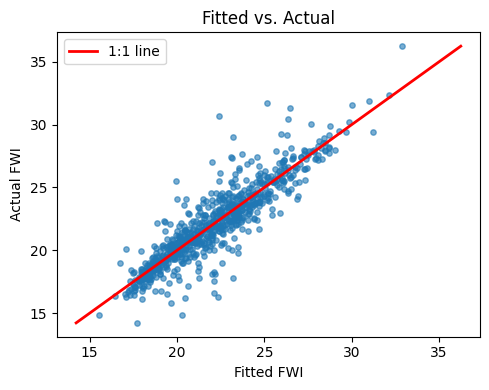

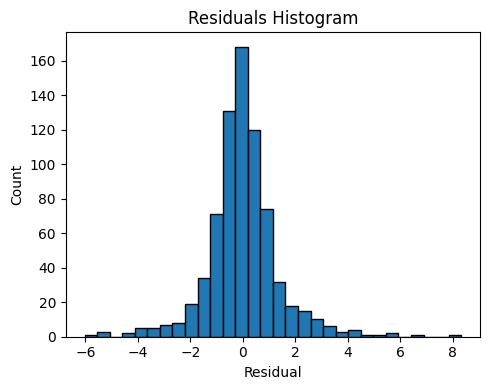

In [13]:
y     = panel_df_th['FWI'].values
yhat  = mlr_model.fittedvalues.values
resid = mlr_model.resid.values

plt.figure(figsize=(5, 4))
plt.scatter(yhat, y, s=15, alpha=0.6)
mn, mx = np.min([y, yhat]), np.max([y, yhat])
plt.plot([mn, mx], [mn, mx], lw=2, color='red', label='1:1 line')
plt.xlabel('Fitted FWI')
plt.ylabel('Actual FWI')
plt.title('Fitted vs. Actual')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(5, 4))
plt.hist(resid, bins=30, edgecolor='black')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.title('Residuals Histogram')
plt.tight_layout()
plt.show()

## 10. Variance Inflation Factors (VIF)

VIF > 10 typically indicates problematic multicollinearity.

In [15]:
cols           = ['FWI', 'tasmax', 'pr', 'hursmin', 'sfcWind']
panel_df_clean = panel_df_th.dropna(subset=cols).copy()

X = panel_df_clean[['tasmax', 'pr', 'hursmin', 'sfcWind']]
X = add_constant(X)

vif_data = pd.DataFrame({
    'Variable': X.columns,
    'VIF'     : [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
})
print(vif_data.round(2))

  Variable       VIF
0    const  18834.77
1   tasmax      2.37
2       pr      1.44
3  hursmin      2.96
4  sfcWind      1.45
